Selected target: X11  (parents=3, children=4)
Network: Random20
Target : X11 = '1'
Nodes  : 20, Edges: 42, Evidence: 12

Hunting for patients... (Locking 12 variables as evidence)
Generating batch 1/2 of 10000 random realities...
--> Filled bucket 1.0 with Exact SDP: 1.0000
--> Filled bucket 0.5 with Exact SDP: 0.4758
--> Filled bucket 0.6 with Exact SDP: 0.5999
--> Filled bucket 0.9 with Exact SDP: 0.9038
--> Filled bucket 0.8 with Exact SDP: 0.7856
--> Filled bucket 0.7 with Exact SDP: 0.7385
All buckets filled successfully!

Harvested patients:
  SDP=0.5: exact=0.4758  H_active=6  H_dsep=1
  SDP=0.6: exact=0.5999  H_active=6  H_dsep=1
  SDP=0.7: exact=0.7385  H_active=3  H_dsep=4
  SDP=0.8: exact=0.7856  H_active=7  H_dsep=0
  SDP=0.9: exact=0.9038  H_active=7  H_dsep=0
  SDP=1.0: exact=1.0000  H_active=7  H_dsep=0


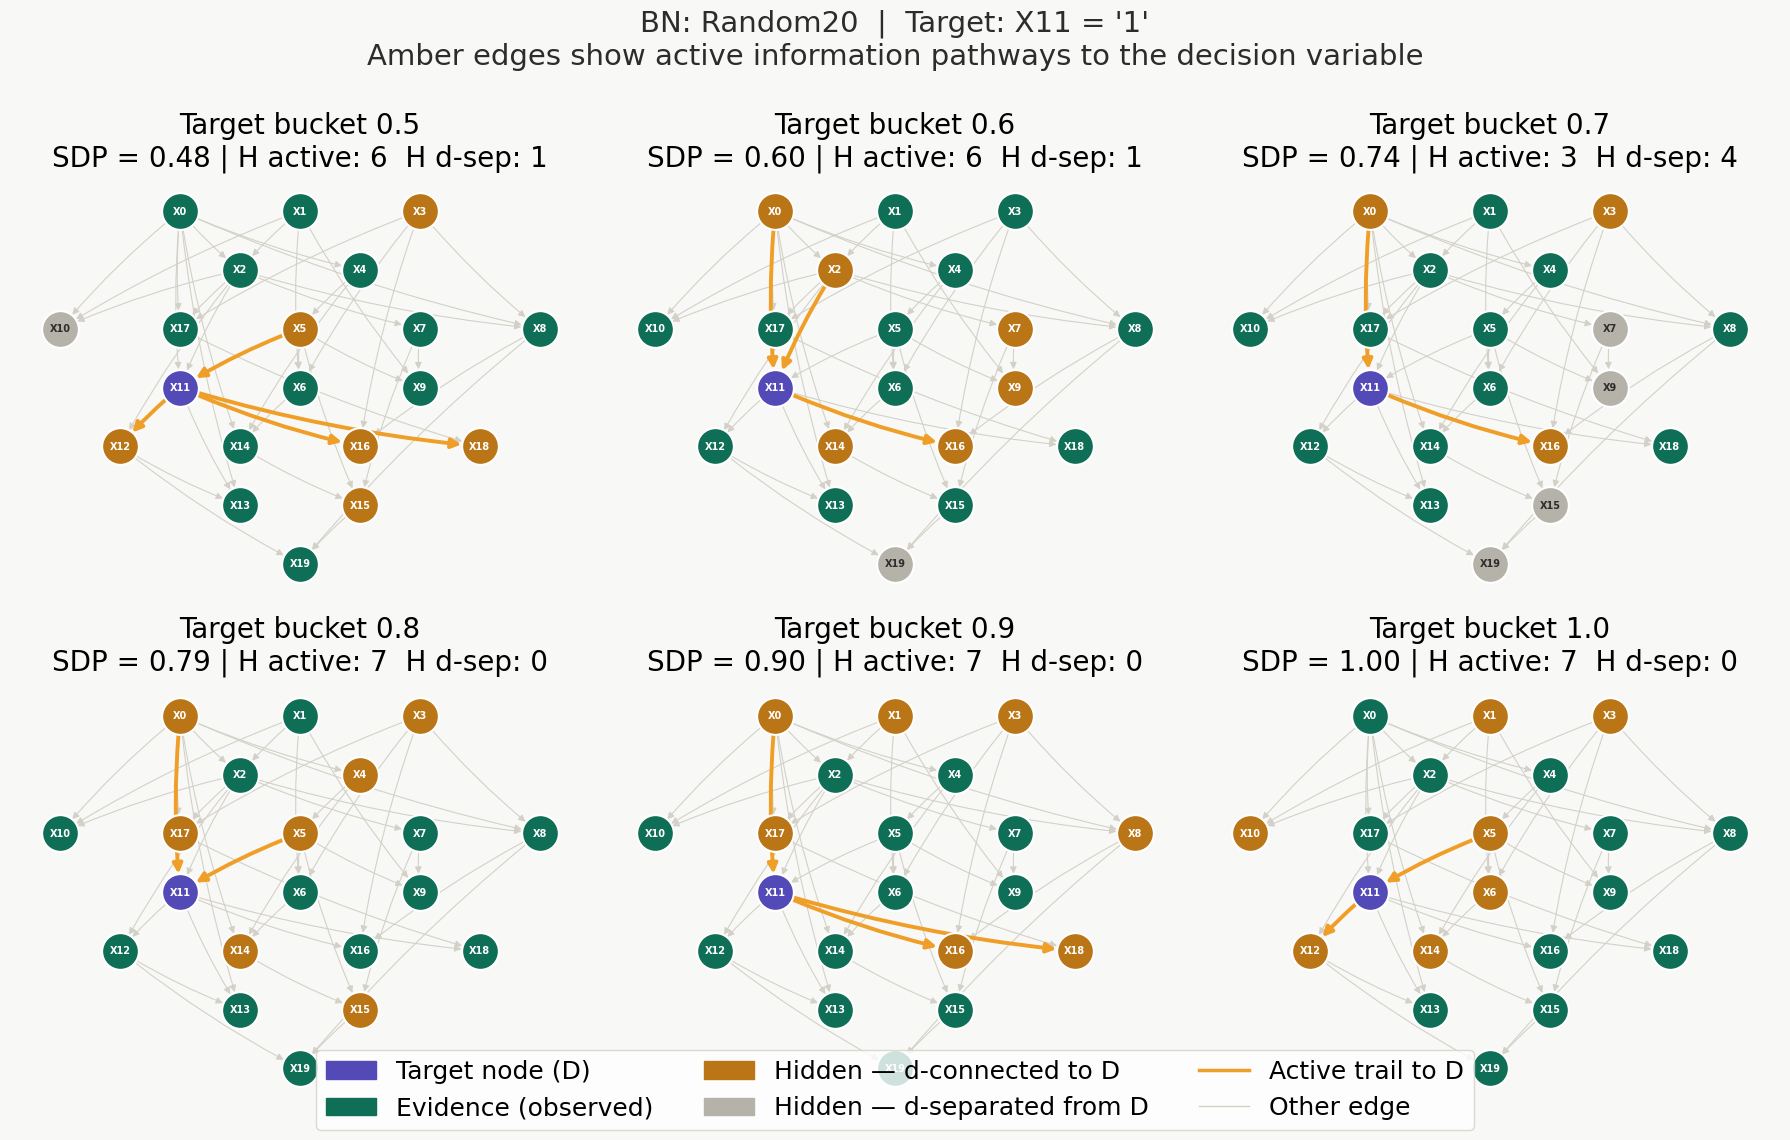

Saved: sdp_network_cases.png


In [23]:
import random
import math
import itertools
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx
from pgmpy.models import BayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.estimators import MaximumLikelihoodEstimator
from monte_carlo_sdp import *

# ── 1. Generate a random 20-node binary BN ────────────────────────────────────

def select_optimal_target_node(bn):
    """
    Selects a target node deeply embedded in the network (highest degree).
    Highly connected nodes provide a smooth, responsive probability gradient 
    for the Hill Climber, making extreme SDP values (0.90+) reachable.
    """
    best_node = None
    max_degree = -1
    
    for node in bn.nodes():
        # Ensure it's a binary node
        if len(bn.get_cpds(node).state_names[node]) != 2:
            continue
            
        degree = len(bn.get_parents(node)) + len(bn.get_children(node))
        if degree > max_degree:
            max_degree = degree
            best_node = node
            
    # Fallback if no binary nodes exist (rare)
    if best_node is None:
        return random.choice(list(bn.nodes()))
        
    return best_node

import networkx as nx

def get_active_trail_edges(bn, target, evidence_vars, h_active):
    """
    Returns the set of directed edges (u, v) that lie on an active trail
    between the h_active nodes and the target, using pgmpy's built-in
    active_trail_nodes — no manual d-separation logic.

    An edge u→v lies on an active trail from H to target iff:
      - u is d-connected to some h_active node given evidence
        (i.e. u ∈ active_trail_nodes(h_active, observed))
      - v is d-connected to the target given evidence
        (i.e. v ∈ active_trail_nodes([target], observed))
    """
    if not h_active:
        return set()

    # All nodes d-connected to ANY h_active node given the evidence
    h_reachable_dict  = bn.active_trail_nodes(
        variables=h_active, observed=evidence_vars
    )
    reachable_from_H  = set().union(*h_reachable_dict.values())

    # All nodes d-connected to the target given the evidence
    t_reachable_dict  = bn.active_trail_nodes(
        variables=[target], observed=evidence_vars
    )
    reachable_from_target = t_reachable_dict[target]

    # A directed edge u→v is on an active trail from H to target iff
    # u is reachable from H  AND  v can reach the target
    return {
        (u, v) for u, v in bn.edges()
        if u in reachable_from_H and v in reachable_from_target
    }



def select_optimal_target_node2(bn):
    """
    Selects a binary target node that is well-embedded as a CHILD in the
    network — i.e. has parents whose states can shift its posterior.

    A node with no parents has a fixed prior: evidence can never update it,
    the decision boundary never moves, and interesting SDP values are
    unreachable. We therefore require at least one parent and rank by
    n_parents first, n_children second.
    """
    best_node   = None
    best_score  = (-1, -1)   # (n_parents, n_children)

    for node in bn.nodes():
        cpd = bn.get_cpds(node)

        # Must be binary
        if len(cpd.state_names[node]) != 2:
            continue

        n_parents  = len(bn.get_parents(node))
        n_children = len(list(bn.get_children(node)))

        # Hard requirement: must have at least one parent so that evidence
        # can influence its posterior through the network
        if n_parents == 0:
            continue

        score = (n_parents, n_children)
        if score > best_score:
            best_score = score
            best_node  = node

    # Fallback: if every binary node is a root (unusual), relax the
    # parent requirement and just pick highest total degree
    if best_node is None:
        print("Warning: no binary node with parents found — "
              "falling back to highest-degree binary node.")
        for node in bn.nodes():
            if len(bn.get_cpds(node).state_names[node]) != 2:
                continue
            n_parents  = len(bn.get_parents(node))
            n_children = len(list(bn.get_children(node)))
            score = (n_parents + n_children, n_parents)
            if score > best_score:
                best_score = score
                best_node  = node

    if best_node is None:
        best_node = random.choice(list(bn.nodes()))
        print(f"Warning: using random fallback target: {best_node}")

    n_pa = len(bn.get_parents(best_node))
    n_ch = len(list(bn.get_children(best_node)))
    print(f"Selected target: {best_node}  "
          f"(parents={n_pa}, children={n_ch})")
    return best_node

def make_random_bn(n_nodes=20, edge_prob=0.25, seed=42):
    """
    Creates a random binary BN with n_nodes nodes.
    Uses a random DAG (nodes are topologically ordered 0..n-1,
    edges only go forward so no cycles are possible).
    CPTs are drawn randomly to produce a mix of low and high entropy.
    """
    rng = random.Random(seed)
    np.random.seed(seed)

    nodes  = [f"X{i}" for i in range(n_nodes)]
    edges  = []

    # Random DAG: for each pair (i, j) with i < j, add edge with prob edge_prob
    for i in range(n_nodes):
        for j in range(i + 1, n_nodes):
            if rng.random() < edge_prob:
                # Cap in-degree at 3 to keep CPTs tractable
                if sum(1 for (_, t) in edges if t == nodes[j]) < 3:
                    edges.append((nodes[i], nodes[j]))

    bn = BayesianNetwork(edges)
    bn.add_nodes_from(nodes)

    # Fit random CPTs
    for node in bn.nodes():
        parents = list(bn.get_parents(node))
        n_parent_configs = 2 ** len(parents)

        # Randomly choose between "peaked" (low entropy) and "flat" (high entropy)
        # CPTs to create structural variety
        if rng.random() < 0.4:
            # Peaked CPT: one state strongly preferred
            vals = []
            for _ in range(n_parent_configs):
                p = rng.uniform(0.75, 0.99)
                if rng.random() < 0.5:
                    vals.append([p, 1 - p])
                else:
                    vals.append([1 - p, p])
        else:
            # Flat CPT: close to uniform
            vals = []
            for _ in range(n_parent_configs):
                p = rng.uniform(0.35, 0.65)
                vals.append([p, 1 - p])

        values = np.array(vals).T   # shape (2, n_parent_configs)

        cpd = TabularCPD(
            variable=node,
            variable_card=2,
            values=values,
            evidence=parents if parents else None,
            evidence_card=[2] * len(parents) if parents else None,
            state_names={node: ['0', '1'], **{p: ['0', '1'] for p in parents}}
        )
        bn.add_cpds(cpd)

    assert bn.check_model(), "Generated BN failed check_model()"
    bn.name = "Random20"
    return bn


# ── 2. Network plot with role highlighting and active trails ──────────────────

# Colour scheme
PALETTE = {
    'target':   {'node': '#534AB7', 'label': 'white',  'edge': '#534AB7'},  # purple
    'evidence': {'node': '#0F6E56', 'label': 'white',  'edge': '#0F6E56'},  # teal
    'h_active': {'node': '#BA7517', 'label': 'white',  'edge': '#BA7517'},  # amber
    'h_dsep':   {'node': '#B4B2A9', 'label': '#2C2C2A','edge': '#888780'},  # gray
}
ACTIVE_TRAIL_COLOR  = '#EF9F27'   # bright amber for active trail edges
REGULAR_EDGE_COLOR  = '#D3D1C7'   # light gray for regular edges
ACTIVE_TRAIL_WIDTH  = 2.8
REGULAR_EDGE_WIDTH  = 0.8


def plot_bn_sdp_case(bn, target, evidence, sdp_value, ax, title=None):

    evidence_vars = list(evidence.keys())
    hidden_vars   = [n for n in bn.nodes()
                     if n not in evidence_vars and n != target]

    h_active = [v for v in hidden_vars
                if bn.is_dconnected(target, v, observed=evidence_vars)]
    h_dsep   = [v for v in hidden_vars if v not in h_active]

    role = {}
    for n in bn.nodes():
        if n == target:          role[n] = 'target'
        elif n in evidence_vars: role[n] = 'evidence'
        elif n in h_active:      role[n] = 'h_active'
        else:                    role[n] = 'h_dsep'

    G = nx.DiGraph(bn.edges())
    G.add_nodes_from(bn.nodes())

    try:
        layers = list(nx.topological_generations(G))
        pos    = {}
        for depth, layer in enumerate(layers):
            layer = sorted(layer)
            for i, node in enumerate(layer):
                x = (i - (len(layer) - 1) / 2.0) * 2.2
                y = -depth * 1.8
                pos[node] = (x, y)
    except Exception:
        pos = nx.spring_layout(G, seed=0)

    # ── Grab the directed active trail edges ─────────────────────────────
    all_active_trail_edges = get_active_trail_edges(
        bn, target, evidence_vars, h_active
    )

    # ── FILTER: Only keep active edges directly connected to the target ──
    target_active_edges = { (u, v) for u, v in all_active_trail_edges 
                            if u == target or v == target }

    dag_edges = list(bn.edges())
    
    # Strictly check the exact (u, v) tuple against the filtered set
    trail_edges_directed   = [(u, v) for u, v in dag_edges
                               if (u, v) in target_active_edges]
    regular_edges_directed = [(u, v) for u, v in dag_edges
                               if (u, v) not in target_active_edges]

    # Draw regular edges (gray)
    nx.draw_networkx_edges(
        G, pos, ax=ax, edgelist=regular_edges_directed,
        edge_color=REGULAR_EDGE_COLOR, width=REGULAR_EDGE_WIDTH,
        arrows=True, arrowsize=10,
        connectionstyle='arc3,rad=0.05', node_size=700,
    )
    
    # Draw active trail edges (amber)
    if trail_edges_directed:
        nx.draw_networkx_edges(
            G, pos, ax=ax, edgelist=trail_edges_directed,
            edge_color=ACTIVE_TRAIL_COLOR, width=ACTIVE_TRAIL_WIDTH,
            arrows=True, arrowsize=14,
            connectionstyle='arc3,rad=0.05', node_size=700,
            style='solid'
        )

    # Draw nodes by role
    for r, p in PALETTE.items():
        nodelist = [n for n in G.nodes() if role.get(n) == r]
        if not nodelist:
            continue
        nx.draw_networkx_nodes(
            G, pos, ax=ax, nodelist=nodelist,
            node_color=p['node'], node_size=700,
            linewidths=1.5, edgecolors='white',
        )

    # Add Labels
    for node, (x, y) in pos.items():
        ax.text(x, y, node, ha='center', va='center',
                fontsize=7, fontweight='bold',
                color=PALETTE[role[node]]['label'], zorder=5)

    ax.set_title(
        f"{title or ''}\nSDP = {sdp_value:.2f} | "
        f"H active: {len(h_active)}  H d-sep: {len(h_dsep)}",
        fontsize=20, pad=6
    )
    ax.axis('off')

def plot_all_sdp_cases(bn, target, target_value, harvested_data):
    """
    Plots one panel per SDP bucket found in harvested_data.
    Each panel shows the network with role colouring and active trails.
    """
    filled = {k: v for k, v in harvested_data.items() if v is not None}
    n      = len(filled)
    if n == 0:
        print("No filled buckets to plot.")
        return

    ncols = min(3, n)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols,
                              figsize=(ncols * 6, nrows * 5.5),
                              facecolor='#F8F8F6')

    axes_flat = np.array(axes).flatten() if n > 1 else [axes]

    for ax_idx, (target_sdp, result) in enumerate(sorted(filled.items())):
        patient, exact_sdp = result
        ax = axes_flat[ax_idx]
        ax.set_facecolor('#F8F8F6')
        plot_bn_sdp_case(
            bn, target, patient, exact_sdp, ax,
            title=f"Target bucket {target_sdp}"
        )

    # Hide unused axes
    for i in range(len(filled), len(axes_flat)):
        axes_flat[i].set_visible(False)

    # Shared legend
    legend_items = [
        mpatches.Patch(color=PALETTE['target']['node'],   label='Target node (D)'),
        mpatches.Patch(color=PALETTE['evidence']['node'], label='Evidence (observed)'),
        mpatches.Patch(color=PALETTE['h_active']['node'], label='Hidden — d-connected to D'),
        mpatches.Patch(color=PALETTE['h_dsep']['node'],   label='Hidden — d-separated from D'),
        plt.Line2D([0], [0], color=ACTIVE_TRAIL_COLOR,
                   linewidth=2.5, label='Active trail to D'),
        plt.Line2D([0], [0], color=REGULAR_EDGE_COLOR,
                   linewidth=1.0, label='Other edge'),
    ]
    fig.legend(handles=legend_items, loc='lower center',
               ncol=3, fontsize=18, frameon=True,
               bbox_to_anchor=(0.5, -0.02),
               facecolor='white', edgecolor='#D3D1C7')

    fig.suptitle(
        f"BN: {bn.name}  |  Target: {target} = '{target_value}'\n"
        f"Amber edges show active information pathways to the decision variable",
        fontsize=21, y=1.01, fontweight='normal', color='#2C2C2A'
    )
    plt.tight_layout()
    plt.savefig("sdp_network_cases.png", dpi=150,
                bbox_inches='tight', facecolor='#F8F8F6')
    plt.show()
    print("Saved: sdp_network_cases.png")


# ── 3. Run everything ─────────────────────────────────────────────────────────

# Build the network
model = make_random_bn(n_nodes=20, edge_prob=0.25, seed=42)

# Select target and evidence split
target        = select_optimal_target_node2(model)
#target = np.random.choice(model.nodes())
target_states = model.get_cpds(target).state_names[target]
target_value  = target_states[1]

all_nodes     = [n for n in model.nodes() if n != target]
n_evidence    = 12

print(f"Network: {model.name}")
print(f"Target : {target} = '{target_value}'")
print(f"Nodes  : {model.number_of_nodes()}, "
      f"Edges: {model.number_of_edges()}, "
      f"Evidence: {n_evidence}")

# Harvest patients for each SDP bucket
target_sdps  = [0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
harvested    = find_exact_experimental_patients_random(
    model, target, target_value,
    decision_threshold=0.8,
    n_evidence=n_evidence,
    buckets=target_sdps,
    batch_size=10_000
)

# Print summary
print("\nHarvested patients:")
for sdp, result in sorted(harvested.items()):
    if result is None:
        print(f"  SDP={sdp}: not found")
    else:
        patient, exact = result
        ev_vars   = list(patient.keys())
        hidden    = [n for n in model.nodes() if n not in ev_vars and n != target]
        n_active  = sum(1 for v in hidden
                        if model.is_dconnected(target, v, observed=ev_vars))
        n_dsep    = len(hidden) - n_active
        print(f"  SDP={sdp}: exact={exact:.4f}  "
              f"H_active={n_active}  H_dsep={n_dsep}")

# Plot
plot_all_sdp_cases(model, target, target_value, harvested)